# Student Stress Level Prediction
## Regression-Based Approach with 3-Category Stress Binning

This notebook predicts student stress levels using a regression model trained on real survey data.  
Predicted continuous stress scores (1–10) are then binned into three categories:

| Category | Range |
|----------|-------|
| **Low**  | 1 – 3 |
| **Average** | 4 – 6 |
| **High** | 7 – 10 |

**Features used:** relationship status, financial pressure (rent/work hours), social habits, drug use, study behaviour, sleep, and more.

## Section 1 — Import Required Libraries

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section 2 — Load & Inspect the Real Survey Data

In [185]:
DATA_PATH = "data1001_survey_data_2025_S2-1.csv"

raw = pd.read_csv(DATA_PATH)

# Keep only rows where consent was given
raw = raw[raw["consent"].str.contains("consent to take part", na=False, case=False)].copy()

print(f"Rows after consent filter: {len(raw)}")
print(f"Columns: {list(raw.columns)}")
raw.head(3)

Rows after consent filter: 2955
Columns: ['cohort', 'consent', 'age', 'gender', 'country_of_birth', 'country_of_birth_5_TEXT', 'hours_work', 'social_media_use', 'rent', 'friends_count', 'stress', 'highest_speed', 'relationship_status', 'dates', 'standard_drinks', 'countries', 'drug_use_q', 'drug_use_ans', 'student_type', 'mainstream_advanced', 'semesters', 'commute', 'data_interest', 'mark_goal', 'hours_studying', 'lecture_mode', 'study_type', 'learner_style']


,cohort,consent,age,gender,country_of_birth,country_of_birth_5_TEXT,hours_work,social_media_use,rent,friends_count,...,student_type,mainstream_advanced,semesters,commute,data_interest,mark_goal,hours_studying,lecture_mode,study_type,learner_style
0,2024S2,I DO NOT consent to take part in the study,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024S2,I consent to take part in the study,18.0,Female,Australia,NaN,40.0,4.0,400.0,2.0,...,International,DATA1001,4.0,70.0,9.0,50.0,5.0,Live in the Lecture Theatre,I work steadily all semester,Style 1
2,2024S2,I consent to take part in the study,19.0,Female,Other Please Specify,NaN,40.0,200.0,200.8,0.0,...,International,DATA1901,8.3,5.0,4.0,50.0,25.0,Other,It changes depending on the subject,Style 3


## Section 3 — Feature Engineering & Stress Score Binning

In [186]:
# ── Column definitions ────────────────────────────────────────────────────────
NUMERIC_COLS = [
    "age", "hours_work", "social_media_use", "rent",
    "friends_count", "highest_speed", "dates", "standard_drinks",
    "countries", "semesters", "commute", "data_interest",
    "mark_goal", "hours_studying",
]
CATEGORICAL_COLS = [
    "gender", "relationship_status", "drug_use_ans",
    "student_type", "mainstream_advanced", "lecture_mode",
    "study_type", "learner_style",
]
TARGET = "stress"

# ── Build working dataframe ───────────────────────────────────────────────────
cols_needed = NUMERIC_COLS + CATEGORICAL_COLS + [TARGET]
df = raw[cols_needed].copy()

# ── Step 1: Outlier clipping — 1st to 99th percentile per numeric column ─────
for col in NUMERIC_COLS:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lo, hi)

# ── Step 2: Impute missing values ─────────────────────────────────────────────
#    Numeric → median (robust to skew); Categorical → mode
for col in NUMERIC_COLS:
    df[col] = df[col].fillna(df[col].median())
for col in CATEGORICAL_COLS:
    mode_val = df[col].mode()
    df[col] = df[col].fillna(mode_val[0] if not mode_val.empty else "Unknown")

# ── Step 3: Derived / engineered features ────────────────────────────────────
# Financial pressure: rent per worked hour (higher → more financial burden)
df["financial_pressure"] = (
    df["rent"] / df["hours_work"].replace(0, np.nan)
).fillna(df["rent"])

# Work-to-study ratio: balance between earning and learning obligations
df["work_study_ratio"] = (
    df["hours_work"] / df["hours_studying"].replace(0, np.nan)
).fillna(df["hours_work"])

# Social engagement: friends relative to social media time (quality vs quantity)
df["social_engagement"] = (
    df["friends_count"] / df["social_media_use"].replace(0, np.nan)
).fillna(df["friends_count"])

# Clip derived features to 99th percentile to suppress extreme ratios
for col in ["financial_pressure", "work_study_ratio", "social_engagement"]:
    df[col] = df[col].clip(0, df[col].quantile(0.99))

DERIVED_COLS = ["financial_pressure", "work_study_ratio", "social_engagement"]

# ── Step 4: Label-encode categoricals — FOR EDA / correlation plots ONLY ─────
#    The modeling pipeline (Section 5) uses OneHotEncoding instead.
le_dict = {}
df_eda = df.copy()
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_eda[col] = le.fit_transform(df_eda[col].astype(str))
    le_dict[col] = le

# ── Step 5: Drop rows with missing target ─────────────────────────────────────
df     = df.dropna(subset=[TARGET])
df_eda = df_eda.loc[df.index]

# ── Step 6: Bin continuous stress score into 3 categories ─────────────────────
def bin_stress(score):
    """Map a 0–10 stress score → Low / Average / High."""
    if score <= 3:   return "Low (1-3)"
    elif score <= 6: return "Average (4-6)"
    else:            return "High (7-10)"

df["stress_category"]     = df[TARGET].apply(bin_stress)
df_eda["stress_category"] = df_eda[TARGET].apply(bin_stress)
CATEGORY_ORDER = ["Low (1-3)", "Average (4-6)", "High (7-10)"]

print(f"Dataset shape     : {df.shape}")
print(f"Numeric features  : {NUMERIC_COLS}")
print(f"Derived features  : {DERIVED_COLS}")
print(f"Categorical feat. : {CATEGORICAL_COLS}")
print("\nStress category distribution:")
print(df["stress_category"].value_counts().reindex(CATEGORY_ORDER))
df.head(4)

Dataset shape     : (2842, 27)
Numeric features  : ['age', 'hours_work', 'social_media_use', 'rent', 'friends_count', 'highest_speed', 'dates', 'standard_drinks', 'countries', 'semesters', 'commute', 'data_interest', 'mark_goal', 'hours_studying']
Derived features  : ['financial_pressure', 'work_study_ratio', 'social_engagement']
Categorical feat. : ['gender', 'relationship_status', 'drug_use_ans', 'student_type', 'mainstream_advanced', 'lecture_mode', 'study_type', 'learner_style']

Stress category distribution:
stress_category
Low (1-3)         773
Average (4-6)    1195
High (7-10)       874
Name: count, dtype: int64


,age,hours_work,social_media_use,rent,friends_count,highest_speed,dates,standard_drinks,countries,semesters,...,student_type,mainstream_advanced,lecture_mode,study_type,learner_style,stress,financial_pressure,work_study_ratio,social_engagement,stress_category
1,18.00,40.0,4.0,400.0,2.0,150.0,0.0,6.0,6.0,4.0,...,International,DATA1001,Live in the Lecture Theatre,I work steadily all semester,Style 1,10.0,10.000000,8.000000,0.500000,High (7-10)
2,19.00,40.0,22.5,200.8,0.0,0.0,0.0,4.3,6.0,8.3,...,International,DATA1901,Other,It changes depending on the subject,Style 3,1.0,5.020000,1.600000,0.000000,Low (1-3)
3,33.59,38.5,2.0,1000.0,100.0,140.0,0.0,0.0,6.0,0.0,...,Domestic,DATA1001,Other,I work steadily all semester,Style 1,5.0,25.974026,3.850000,32.752688,Average (4-6)
4,17.00,10.0,10.0,500.0,1.0,200.0,0.0,0.0,6.0,5.0,...,Domestic,DATA1001,Live in the Lecture Theatre,I work steadily all semester,Style 2,7.0,50.000000,3.333333,0.100000,High (7-10)


## Section 4 — Exploratory Data Analysis (EDA)

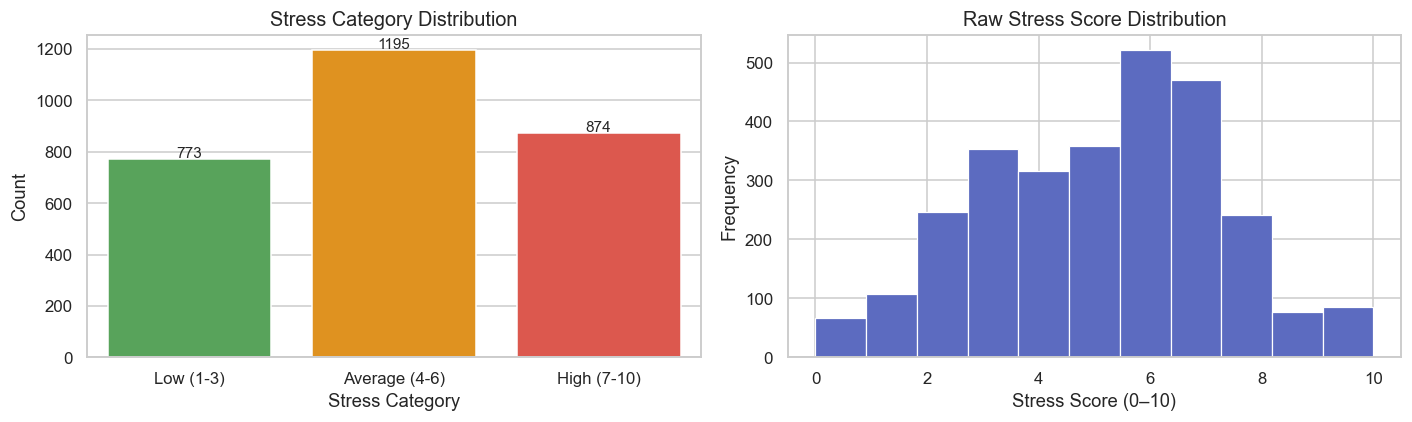

In [187]:
# ── 4a. Stress category distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cat_counts = df["stress_category"].value_counts().reindex(CATEGORY_ORDER)
palette = {"Low (1-3)": "#4CAF50", "Average (4-6)": "#FF9800", "High (7-10)": "#F44336"}

sns.barplot(
    x=cat_counts.index, y=cat_counts.values,
    palette=palette, ax=axes[0], order=CATEGORY_ORDER,
)
axes[0].set_title("Stress Category Distribution", fontsize=13)
axes[0].set_xlabel("Stress Category"); axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha="center", fontsize=10)

axes[1].hist(df[TARGET].dropna(), bins=11, color="#5C6BC0", edgecolor="white", linewidth=0.8)
axes[1].set_title("Raw Stress Score Distribution", fontsize=13)
axes[1].set_xlabel("Stress Score (0–10)"); axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

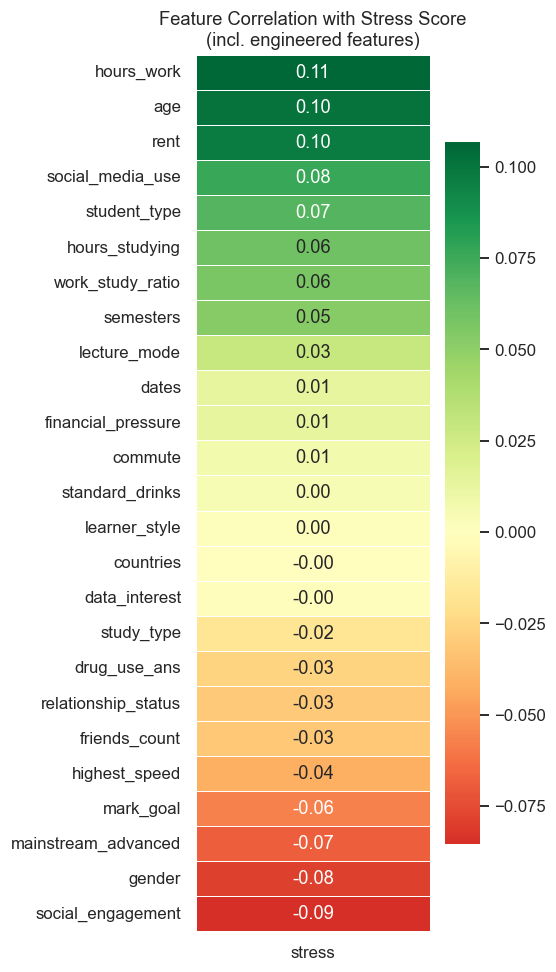

In [188]:
# ── 4b. Correlation heatmap with stress score ─────────────────────────────────
# Uses df_eda (label-encoded categoricals) so all columns are numeric
FEATURE_COLS = NUMERIC_COLS + DERIVED_COLS + CATEGORICAL_COLS
corr_df = df_eda[FEATURE_COLS + [TARGET]].corr()
stress_corr = corr_df[[TARGET]].drop(TARGET).sort_values(TARGET, ascending=False)

fig, ax = plt.subplots(figsize=(5, 9))
sns.heatmap(
    stress_corr, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.5, linecolor="white", ax=ax, cbar_kws={"shrink": 0.8},
)
ax.set_title("Feature Correlation with Stress Score\n(incl. engineered features)", fontsize=12)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

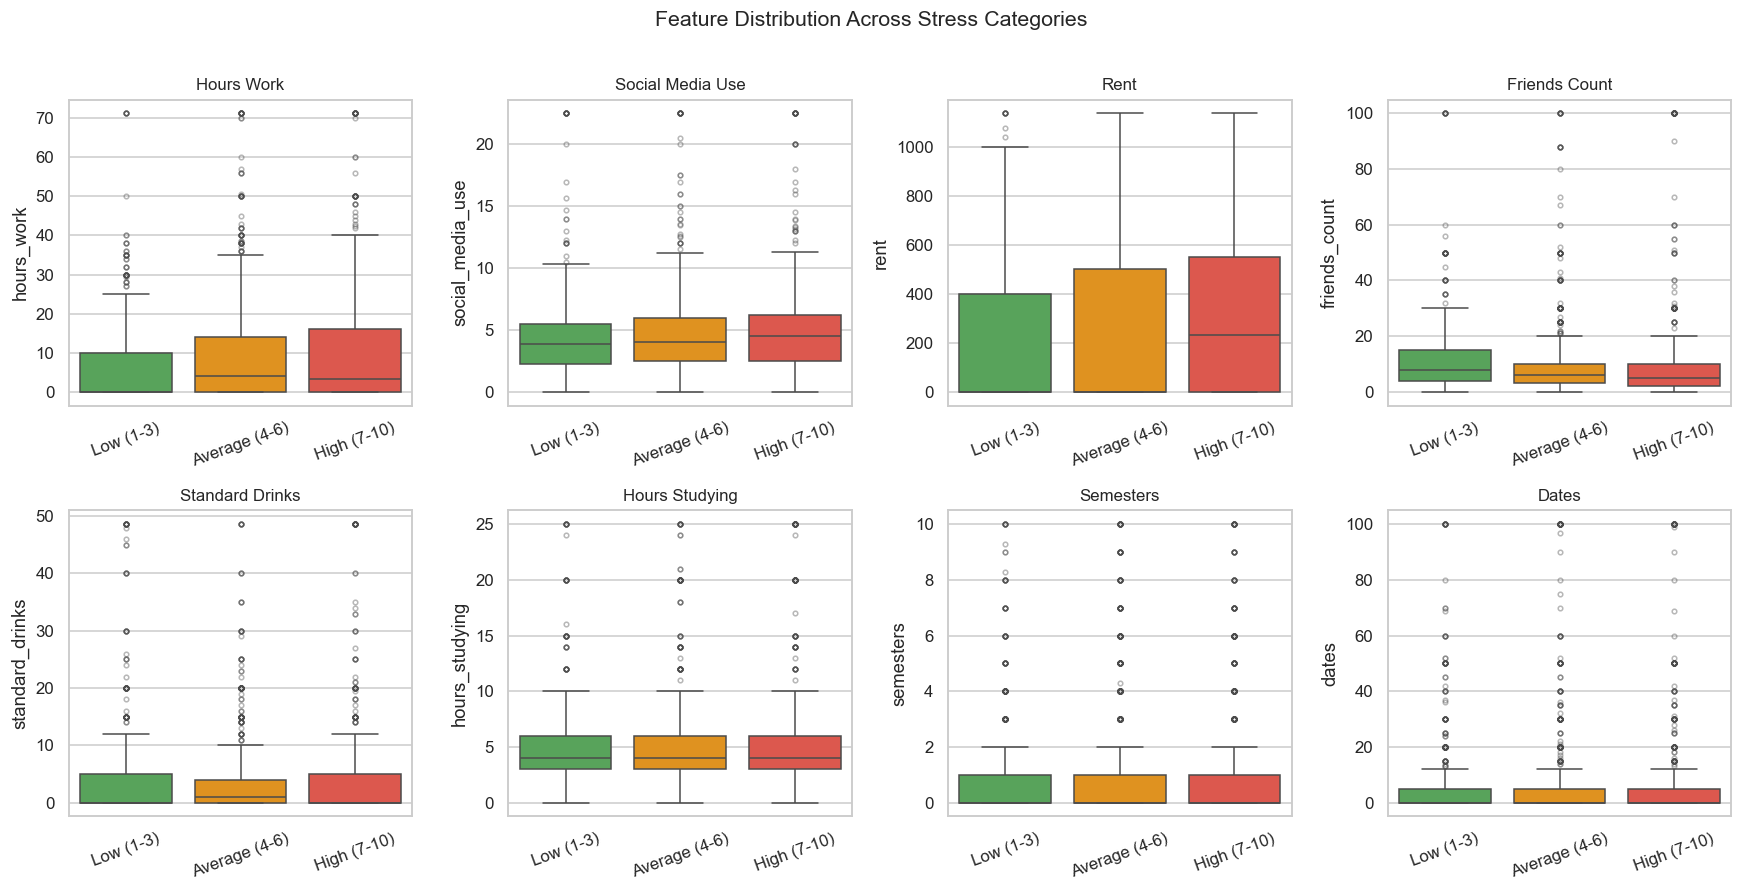

In [189]:
# ── 4c. Box plots: key features across stress categories ─────────────────────
key_features = ["hours_work", "social_media_use", "rent", "friends_count",
                "standard_drinks", "hours_studying", "semesters", "dates"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    plot_df = df[[feat, "stress_category"]].dropna()
    sns.boxplot(
        data=plot_df, x="stress_category", y=feat,
        order=CATEGORY_ORDER, palette=palette, ax=axes[i],
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    axes[i].set_title(feat.replace("_", " ").title(), fontsize=11)
    axes[i].set_xlabel(""); axes[i].tick_params(axis="x", rotation=20)

plt.suptitle("Feature Distribution Across Stress Categories", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Section 5 — Data Preprocessing & Train-Test Split

In [190]:
# ── Feature sets for modeling ─────────────────────────────────────────────────
ALL_NUMERIC = NUMERIC_COLS + DERIVED_COLS   # 14 raw + 3 engineered = 17
ALL_CATS    = CATEGORICAL_COLS              # 8 nominal columns

# ── Rebuild X with: numeric from df (clipped+derived), strings from raw ───────
#    df already has outlier-clipped numerics and derived features computed.
#    We restore original string categoricals from raw so OHE works correctly
#    (df has label-integers for EDA; pipeline needs the real strings).
X_num = df[ALL_NUMERIC].copy()
X_cat = raw.loc[df.index, ALL_CATS].fillna("Unknown")
X_raw = pd.concat([X_num, X_cat], axis=1)

y_continuous = df[TARGET]
y_category   = df["stress_category"]

# ── Preprocessing pipeline ────────────────────────────────────────────────────
#    Numeric  : median imputation → StandardScaler
#    Categorical: most-frequent imputation → OneHotEncoder (no ordinal assumption)
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, ALL_NUMERIC),
    ("cat", categorical_transformer, ALL_CATS),
])

# ── 80 / 20 train-test split (stratified on stress category) ─────────────────
X_raw_train, X_raw_test, y_train, y_test, ycat_train, ycat_test = train_test_split(
    X_raw, y_continuous, y_category,
    test_size=0.20, random_state=42, stratify=y_category
)

# ── Fit on train set, transform both ─────────────────────────────────────────
X_train = preprocessor.fit_transform(X_raw_train)
X_test  = preprocessor.transform(X_raw_test)

print(f"Training samples             : {len(X_train)}")
print(f"Test samples                 : {len(X_test)}")
print(f"Raw feature count            : {len(ALL_NUMERIC + ALL_CATS)}")
print(f"Features after OHE expansion : {X_train.shape[1]}")
print("\nPreprocessing pipeline:")
print("  Numeric  → Median Imputer → StandardScaler")
print("  Categorical → Mode Imputer → OneHotEncoder")

Training samples             : 2273
Test samples                 : 569
Raw feature count            : 25
Features after OHE expansion : 44

Preprocessing pipeline:
  Numeric  → Median Imputer → StandardScaler
  Categorical → Mode Imputer → OneHotEncoder


## Section 6 — Model Training: Linear Regression vs Neural Network vs Gradient Boosting

Three models are trained on the same processed features and compared:

| Model | Type | Why include it |
|---|---|---|
| **Multiple Linear Regression** | Linear | Interpretable coefficients; baseline |
| **Neural Network (MLP)** | Non-linear | Learns hidden patterns via hidden layers |
| **Gradient Boosting (GBR)** | Non-linear (tree-based) | Strong ensemble; handles interactions |

✓ Linear Regression trained
✓ Neural Network trained  (stopped at epoch 28)
✓ Gradient Boosting trained


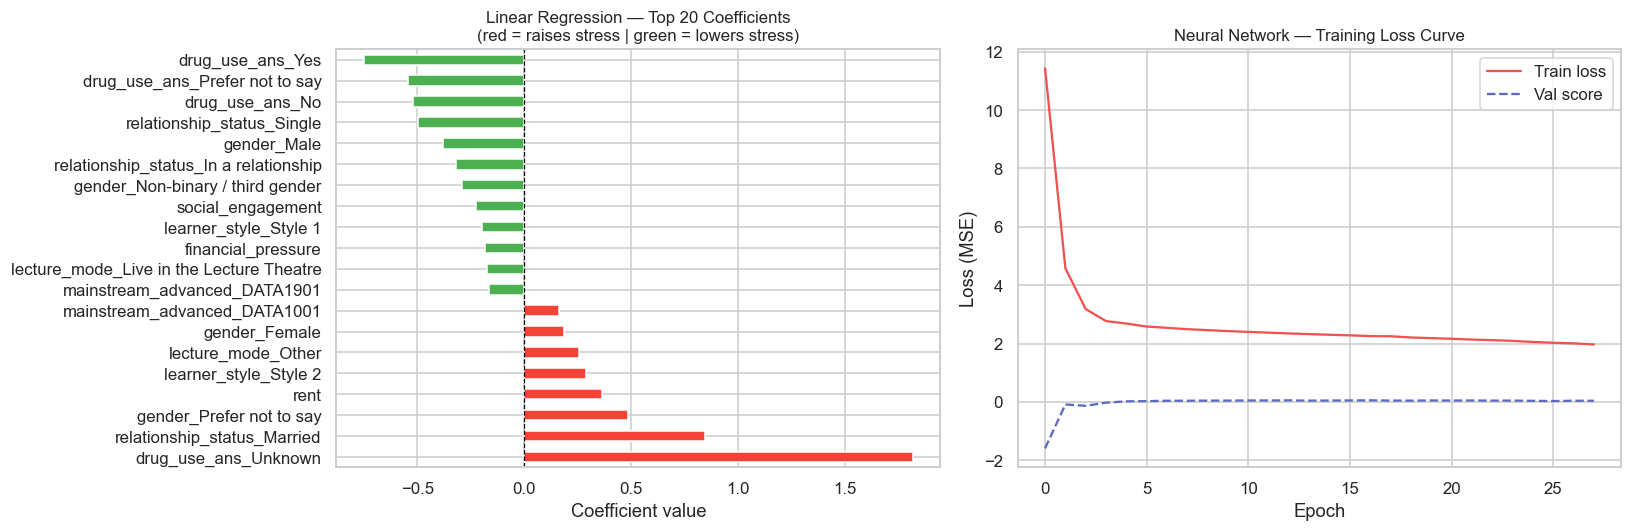

In [191]:
# ── 1. Multiple Linear Regression ─────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
print("✓ Linear Regression trained")

# ── 2. Neural Network — MLP Regressor ─────────────────────────────────────────
nn = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
)
nn.fit(X_train, y_train)
print(f"✓ Neural Network trained  (stopped at epoch {nn.n_iter_})")

# ── 3. Gradient Boosting Regressor (non-linear, tree-based) ───────────────────
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42,
)
gbr.fit(X_train, y_train)
print("✓ Gradient Boosting trained")

# ── Linear Regression coefficient plot (top 20 by absolute magnitude) ─────────
ohe_names = (
    preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(ALL_CATS)
    .tolist()
)
all_feat_names = ALL_NUMERIC + ohe_names
coef_series    = pd.Series(lr.coef_, index=all_feat_names)
top_coef       = coef_series.reindex(coef_series.abs().nlargest(20).index).sort_values()
bar_colors     = ["#F44336" if c > 0 else "#4CAF50" for c in top_coef]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Coefficient plot
top_coef.plot(kind="barh", color=bar_colors, ax=axes[0])
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Linear Regression — Top 20 Coefficients\n(red = raises stress | green = lowers stress)", fontsize=11)
axes[0].set_xlabel("Coefficient value")
axes[0].invert_yaxis()

# NN training loss curve
axes[1].plot(nn.loss_curve_, color="#EF5350", linewidth=1.5, label="Train loss")
if hasattr(nn, "validation_scores_") and nn.validation_scores_ is not None:
    axes[1].plot(nn.validation_scores_, color="#5C6BC0", linewidth=1.5, linestyle="--", label="Val score")
axes[1].set_title("Neural Network — Training Loss Curve", fontsize=11)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss (MSE)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 7 — Convert Regression Output to Stress Categories

In [192]:
# ── Continuous predictions from all 3 models ─────────────────────────────────
preds = {
    "Linear Regression" : np.clip(lr.predict(X_test),  0, 10),
    "Neural Network"    : np.clip(nn.predict(X_test),  0, 10),
    "Gradient Boosting" : np.clip(gbr.predict(X_test), 0, 10),
}

# ── Convert to stress categories using the same bin_stress function ───────────
pred_cats = {
    name: pd.Series(vals).apply(bin_stress).values
    for name, vals in preds.items()
}
y_true_category = ycat_test.values

# ── Sample comparison table (first 10 rows) ───────────────────────────────────
sample = pd.DataFrame({
    "True Score": np.round(y_test.values[:10], 1),
    "True Cat"  : y_true_category[:10],
})
for name, vals in preds.items():
    short = name.split()[0]
    sample[f"{short} Score"] = np.round(vals[:10], 2)
    sample[f"{short} Cat"]   = pred_cats[name][:10]

print("Sample predictions — first 10 rows:")
sample

Sample predictions — first 10 rows:


,True Score,True Cat,Linear Score,Linear Cat,Neural Score,Neural Cat,Gradient Score,Gradient Cat
0,2.0,Low (1-3),6.01,High (7-10),5.98,Average (4-6),6.16,High (7-10)
1,8.0,High (7-10),4.75,Average (4-6),6.56,High (7-10),7.26,High (7-10)
2,7.0,High (7-10),4.91,Average (4-6),5.33,Average (4-6),5.30,Average (4-6)
3,8.0,High (7-10),5.79,Average (4-6),5.49,Average (4-6),5.91,Average (4-6)
4,7.0,High (7-10),4.50,Average (4-6),4.82,Average (4-6),5.00,Average (4-6)
5,6.0,Average (4-6),5.22,Average (4-6),5.19,Average (4-6),5.27,Average (4-6)
6,3.0,Low (1-3),4.73,Average (4-6),4.24,Average (4-6),3.49,Average (4-6)
7,7.0,High (7-10),5.45,Average (4-6),5.12,Average (4-6),6.12,High (7-10)
8,3.0,Low (1-3),4.43,Average (4-6),4.96,Average (4-6),5.84,Average (4-6)
9,8.0,High (7-10),6.02,High (7-10),6.00,High (7-10),5.84,Average (4-6)


## Section 8 — Model Evaluation

In [193]:
# ── 8a. Regression metrics — all 3 models ────────────────────────────────────
print(f"\n{'='*60}")
print(f"  {'MODEL':<22} {'MAE':>6} {'RMSE':>7} {'R²':>9}")
print(f"{'='*60}")
metrics = {}
for name, y_pred in preds.items():
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    metrics[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"  {name:<22} {mae:>6.3f} {rmse:>7.3f} {r2:>9.4f}")
print(f"{'='*60}")
best_r2 = max(metrics, key=lambda m: metrics[m]["R2"])
print(f"\n  Best R²: {best_r2}  ({metrics[best_r2]['R2']:.4f})")


  MODEL                     MAE    RMSE        R²
  Linear Regression       1.894   2.273    0.0396
  Neural Network          1.933   2.312    0.0060
  Gradient Boosting       1.895   2.309    0.0094

  Best R²: Linear Regression  (0.0396)


In [194]:
# ── 8b. Classification report for each model ─────────────────────────────────
for name, y_pred_cat in pred_cats.items():
    acc = accuracy_score(y_true_category, y_pred_cat)
    print(f"\n{'='*52}")
    print(f"  {name}  —  Accuracy: {acc:.1%}")
    print(f"{'='*52}")
    print(classification_report(y_true_category, y_pred_cat, labels=CATEGORY_ORDER))


  Linear Regression  —  Accuracy: 40.6%
               precision    recall  f1-score   support

    Low (1-3)       0.00      0.00      0.00       155
Average (4-6)       0.41      0.90      0.56       239
  High (7-10)       0.36      0.10      0.15       175

     accuracy                           0.41       569
    macro avg       0.26      0.33      0.24       569
 weighted avg       0.28      0.41      0.28       569


  Neural Network  —  Accuracy: 42.5%
               precision    recall  f1-score   support

    Low (1-3)       0.00      0.00      0.00       155
Average (4-6)       0.42      0.87      0.57       239
  High (7-10)       0.47      0.19      0.27       175

     accuracy                           0.43       569
    macro avg       0.30      0.35      0.28       569
 weighted avg       0.32      0.43      0.32       569


  Gradient Boosting  —  Accuracy: 43.1%
               precision    recall  f1-score   support

    Low (1-3)       0.20      0.01      0.01    

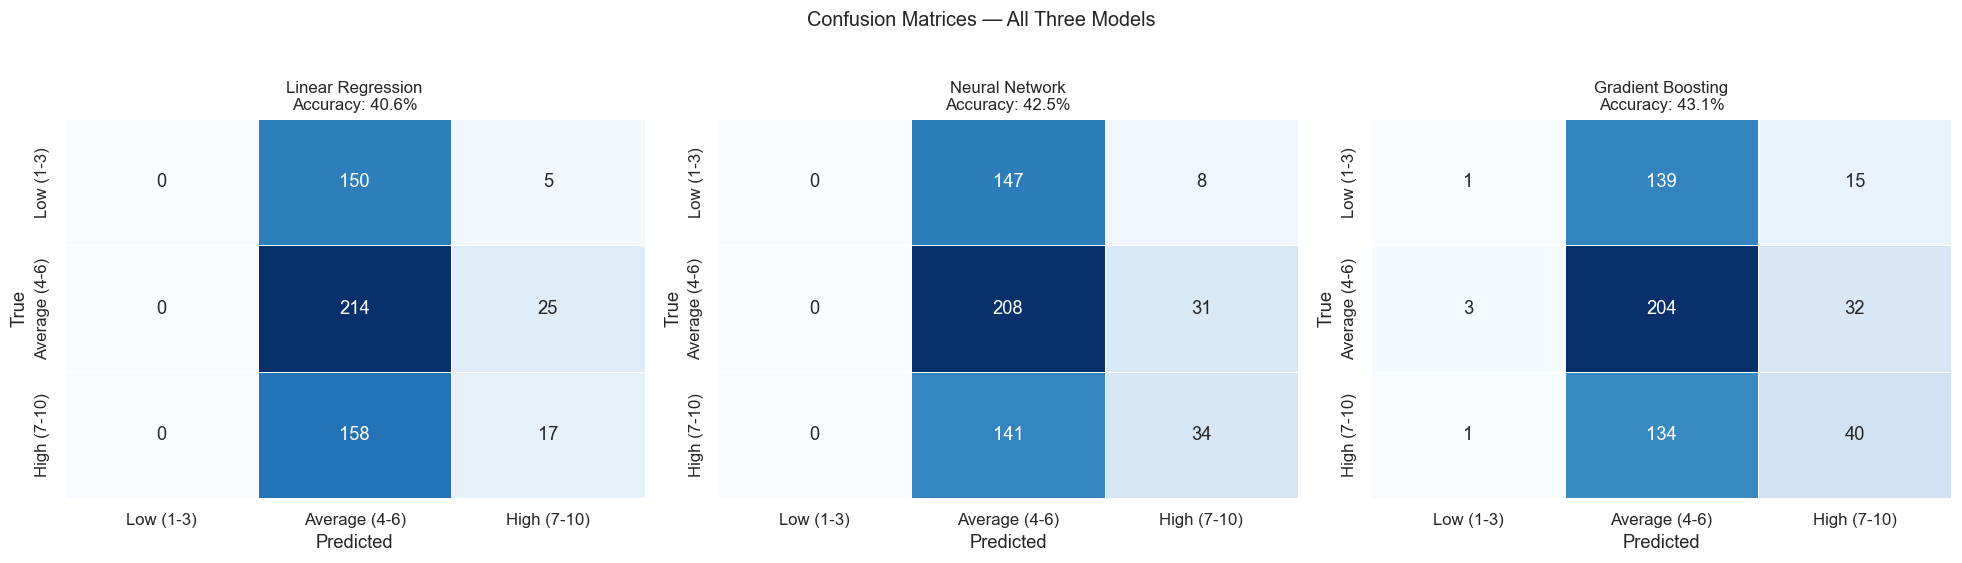

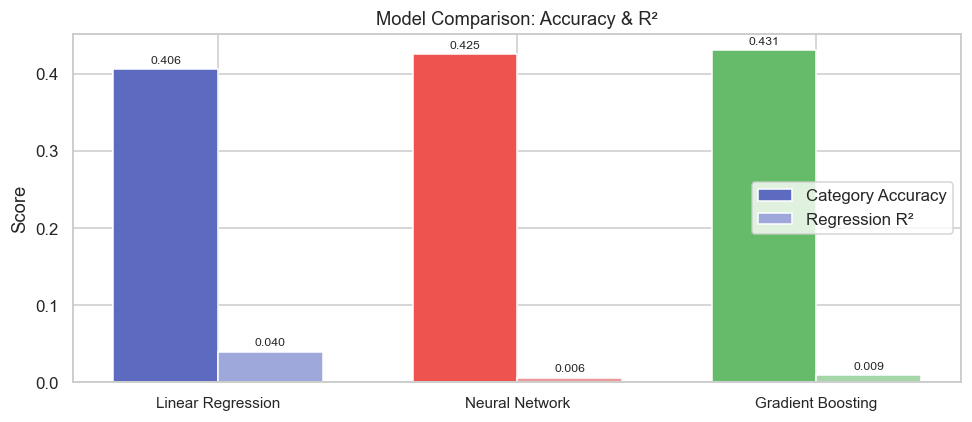

In [195]:
# ── 8c. Confusion matrices — 3 models side by side ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred_cat) in zip(axes, pred_cats.items()):
    cm = confusion_matrix(y_true_category, y_pred_cat, labels=CATEGORY_ORDER)
    sns.heatmap(
        pd.DataFrame(cm, index=CATEGORY_ORDER, columns=CATEGORY_ORDER),
        annot=True, fmt="d", cmap="Blues",
        linewidths=0.5, linecolor="white", ax=ax, cbar=False,
    )
    acc = accuracy_score(y_true_category, y_pred_cat)
    ax.set_title(f"{name}\nAccuracy: {acc:.1%}", fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("Confusion Matrices — All Three Models", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# ── 8d. Model comparison bar chart (Accuracy & R²) ───────────────────────────
model_names = list(pred_cats.keys())
accs = [accuracy_score(y_true_category, pred_cats[n]) for n in model_names]
r2s  = [metrics[n]["R2"] for n in model_names]

x = np.arange(len(model_names))
w = 0.35
colors_acc = ["#5C6BC0", "#EF5350", "#66BB6A"]
colors_r2  = ["#9FA8DA", "#EF9A9A", "#A5D6A7"]

fig2, ax2 = plt.subplots(figsize=(9, 4))
bars1 = ax2.bar(x - w/2, accs, w, color=colors_acc, label="Category Accuracy")
bars2 = ax2.bar(x + w/2, r2s,  w, color=colors_r2,  label="Regression R²")
ax2.set_xticks(x); ax2.set_xticklabels(model_names, fontsize=10)
ax2.set_ylabel("Score"); ax2.set_title("Model Comparison: Accuracy & R²", fontsize=12)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}",
             ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

## Section 9 — Predict Stress Level for a New Student

Enter any combination of student details below to get an instant stress category prediction.

In [ ]:
# ── Define a new student profile ──────────────────────────────────────────────
# Edit numeric values and categorical strings freely.
# The pipeline handles all encoding automatically.
new_student_raw = {
    # Numeric
    "age"               : 21,    "hours_work"        : 30,
    "social_media_use"  : 5,     "rent"              : 800,
    "friends_count"     : 4,     "highest_speed"     : 100,
    "dates"             : 2,     "standard_drinks"   : 10,
    "countries"         : 1,     "semesters"         : 3,
    "commute"           : 45,    "data_interest"     : 6,
    "mark_goal"         : 65,    "hours_studying"    : 8,
    # Categorical (exact survey values)
    "gender"             : "Male",
    "relationship_status": "Single",
    "drug_use_ans"       : "Yes",          # Yes / No / Prefer not to say
    "student_type"       : "Domestic",
    "mainstream_advanced": "DATA1001",
    "lecture_mode"       : "Other",
    "study_type"         : "I work steadily all semester",
    "learner_style"      : "Style 2",
}

# ── Compute derived features (same logic as feature engineering) ──────────────
r = new_student_raw
hw = r["hours_work"]       if r["hours_work"]       != 0 else 1
hs = r["hours_studying"]   if r["hours_studying"]   != 0 else 1
sm = r["social_media_use"] if r["social_media_use"] != 0 else 1

new_row = dict(r)
new_row["financial_pressure"] = r["rent"]          / hw
new_row["work_study_ratio"]   = r["hours_work"]    / hs
new_row["social_engagement"]  = r["friends_count"] / sm

# ── Pass directly through the fitted preprocessing pipeline ──────────────────
new_X_df   = pd.DataFrame([new_row])[ALL_NUMERIC + ALL_CATS]
new_X_proc = preprocessor.transform(new_X_df)

# ── Predict with all 3 models ─────────────────────────────────────────────────
print("=" * 58)
print("    NEW STUDENT STRESS PREDICTION — ALL 3 MODELS")
print("=" * 58)
cat_colors = {"Low (1-3)": "\033[92m", "Average (4-6)": "\033[93m", "High (7-10)": "\033[91m"}
reset = "\033[0m"

for name, model in [("Linear Regression", lr), ("Neural Network", nn), ("Gradient Boosting", gbr)]:
    score = float(np.clip(model.predict(new_X_proc)[0], 0, 10))
    cat   = bin_stress(score)
    col   = cat_colors.get(cat, "")
    print(f"  {name:<22}: {score:.2f}/10  →  {col}{cat}{reset}")
print("=" * 58)

KeyError: "['work_study_ratio', 'social_engagement'] not in index"